# Application of K-Means Clustering and DBSCAN
This case study is compare two popular clustering algorithms, K-means and DBSCAN.

Principle Component Analysis is applied to visualize the data.

The clustering results are evaluated, the algorithms are optimized and the clusters are visualized.

**Note:** The dataset is already in standardized form.

In [1]:
# Import libraries.
import numpy as np 
import pandas as pd 
import warnings
warnings.filterwarnings('ignore')
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import AgglomerativeClustering ,KMeans, DBSCAN
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score
from sklearn import metrics

In [9]:
data=pd.read_csv('cluster_data.csv')

In [10]:
data.columns

Index(['x1', 'x2', 'x3', 'x4', 'x5', 'x6'], dtype='object')

In [11]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4000 entries, 0 to 3999
Data columns (total 6 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   x1      4000 non-null   float64
 1   x2      4000 non-null   float64
 2   x3      4000 non-null   float64
 3   x4      4000 non-null   float64
 4   x5      4000 non-null   float64
 5   x6      4000 non-null   float64
dtypes: float64(6)
memory usage: 187.6 KB


In [12]:
data.sample(10)

,x1,x2,x3,x4,x5,x6
3754,1.370550,-2.533062,0.990494,0.739753,-0.004447,19.465132
497,-1.180336,-1.402710,-0.693548,1.150411,0.013951,7.093578
261,0.728076,-2.989320,-3.166847,2.030931,0.004866,-4.495632
131,-1.831663,-0.140853,0.637299,2.306314,0.004915,5.804842
2565,-0.543513,-1.164750,-0.110397,3.477159,-0.010258,5.016002
2339,1.272883,-10.156107,1.248794,0.487805,0.006261,-3.095993
2707,1.260889,3.800588,2.423213,3.400136,0.009656,-11.805359
1459,-1.813287,0.017122,1.380788,1.976724,0.003619,4.639783
1236,-1.696739,0.232028,0.565560,2.046909,0.003266,7.169586
699,-1.073457,-8.871360,1.637759,2.472274,-0.027145,-5.321869


In [13]:
data.isna().sum()

x1    0
x2    0
x3    0
x4    0
x5    0
x6    0
dtype: int64

In [14]:
data.duplicated().sum()

np.int64(0)

In [16]:
# Apply Principle Component Anaylsis for visualizing the data in 2D space.

pca = PCA()
pca_data = pca.fit_transform(data)
pca_data = pd.DataFrame(pca_data, columns=["pc"+str(i+1) for i in range(len(data.columns))])
pca_data

,pc1,pc2,pc3,pc4,pc5,pc6
0,-7.177875,-8.763586,1.361510,1.107555,-0.514804,-0.002736
1,-10.848233,7.354201,0.243582,-1.701827,1.334084,0.001359
2,-10.934529,-6.058349,0.962290,-1.254643,-1.802970,0.017713
3,-9.512339,-8.888690,0.942949,-0.157453,-0.025676,0.001326
4,0.174162,-2.735380,1.685245,-1.225438,0.943739,-0.015133
...,...,...,...,...,...,...
3995,20.763275,-1.502997,1.740925,0.234792,-0.068808,-0.006162
3996,19.333789,1.626577,-1.323406,0.907242,-0.751101,0.006257
3997,13.355147,1.664088,-1.807643,0.198753,0.857112,0.026368
3998,9.385031,0.930376,-1.379831,2.254259,0.233605,0.002826


# K-means Clustering

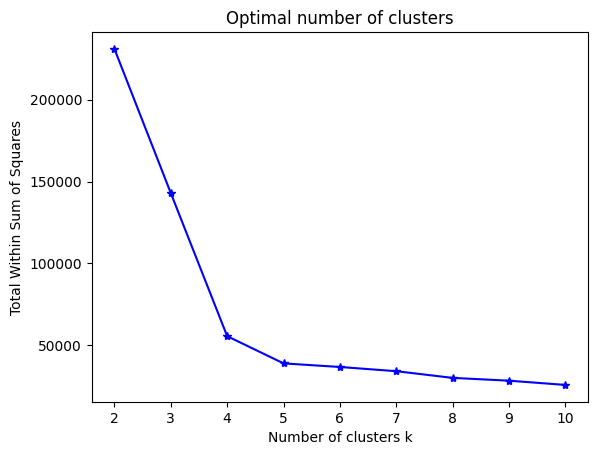

In [17]:
# Plot within-cluster sum of square.

wss = []

K = range(2,11)
for k in K:
    kmeans = KMeans(n_clusters=k, random_state=123)
    kmeans = kmeans.fit(data)
    wss.append(kmeans.inertia_)
plt.plot(K, wss, "b*-")
plt.xlabel("Number of clusters k")
plt.ylabel("Total Within Sum of Squares")
plt.title("Optimal number of clusters")
plt.show()

- Compactness of clustering is measured by total within-cluster sum of square, it should be as small as possible.

- From the within-cluster sum of square (WSS) graph, it can be said that the optimal number of clusters is 4 because the bend in the knee occurs there.

In [18]:
def find_optimal_cluster_number_kmeans(data, lower_bound, upper_bound, random_state):
    
    "Find optimal number of cluster according to silhouette score."
    
    silhouette_average = []
    K = range(lower_bound, upper_bound)

    for k in K:
        kmeans = KMeans(n_clusters=k, random_state=random_state)
        cluster_labels=kmeans.fit_predict(data) 
        silhouette_score = metrics.silhouette_score(data, cluster_labels)
        silhouette_average.append([k, silhouette_score])
        
    silhouette_average = np.array(silhouette_average)
    print("n_clusters =", int(silhouette_average[np.argmax(silhouette_average[:,1:2])][0]),
          "The average silhouette_score is : %.4f" % silhouette_average[np.argmax(silhouette_average[:,1:2])][1])


In [19]:
find_optimal_cluster_number_kmeans(data, 2, 11, random_state=123)

n_clusters = 4 The average silhouette_score is : 0.6718


- Quality of clustering measured by silhouette score approach which determine how well each object lies within its cluster, high average silhouette width implies good clustering.

When number of cluster is 4, average silhouette score is the highest, 0.67. From the both within-cluster sum of sqaure graph and average silhoutte approach, it can be said that optimal number of cluster is 4.

# Visualize K-means

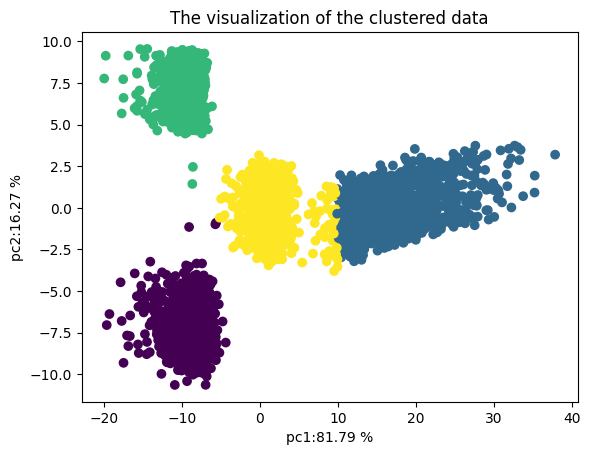

In [21]:
pca_data1 = pca_data[["pc1","pc2"]].copy()
data1 = data.copy() # data1 is created, we do not want to change original data as adding the cluster column.

kmeans = KMeans(n_clusters=4, random_state=2464063)
data1["clusters"] = kmeans.fit_predict(data1)

plt.scatter(pca_data1["pc1"], pca_data1["pc2"], c=data1.clusters)
plt.title("The visualization of the clustered data")
plt.xlabel("pc1:" + "{:.2f}".format(pca.explained_variance_ratio_[0] * 100) + " %")
plt.ylabel("pc2:" + "{:.2f}".format(pca.explained_variance_ratio_[1] * 100) + " %")
plt.show()

- 4 clusters are identified by K-means algorithm. The result is plotted in terms of pc1 and pc2.

# DBSCAN

#### Find optimal parameter setting for DBSCAN.

In [22]:
epsilon = [1,1.25,1.5,1.75, 2,2.25,2.5,2.75, 3,3.25,3.5,3.75, 4]
min_samples = [10,15,20,25]


sil_avg = []
max_value = [0,0,0,0]

for i in range(len(epsilon)):
    for j in range(len(min_samples)):

        db = DBSCAN(min_samples = min_samples[j], eps =epsilon[i]).fit(data)
        #cluster_labels=dbscan.fit_predict(data) 
        core_samples_mask = np.zeros_like(db.labels_, dtype=bool)
        core_samples_mask[db.core_sample_indices_] = True
        labels = db.labels_

        # Number of clusters in labels, ignoring noise if present.
        n_clusters_ = len(set(labels)) - (1 if -1 in labels else 0)
        n_noise_ = list(labels).count(-1)


        silhouette_avg = metrics.silhouette_score(data, labels)
        if silhouette_avg > max_value[3]:
            max_value=(epsilon[i], min_samples[j], n_clusters_, silhouette_avg)
        sil_avg.append(silhouette_avg)

print("epsilon=", max_value[0], 
      "\nmin_sample=", max_value[1],
      "\nnumber of clusters=", max_value[2],
      "\naverage silhouette score= %.4f" % max_value[3])

epsilon= 3.5 
min_sample= 20 
number of clusters= 4 
average silhouette score= 0.6695


- The model (epsilon = 3.5 and min_sample = 20) which has 0.6695 maximum average silhouette score has the optimal number of cluster; 4.

In [23]:
# Apply DBSCAN

db = DBSCAN(eps=3.5, min_samples=20).fit(data)
core_samples_mask = np.zeros_like(db.labels_, dtype=bool)
core_samples_mask[db.core_sample_indices_] = True
labels = db.labels_

# Number of clusters in labels, ignoring noise.
n_clusters_ = len(set(labels)) - (1 if -1 in labels else 0)
n_noise_ = list(labels).count(-1)

print('Estimated number of clusters: %d' % n_clusters_)
print('Estimated number of noise points: %d' % n_noise_)
print("Silhouette Coefficient: %0.3f"
      % metrics.silhouette_score(data, labels))

Estimated number of clusters: 4
Estimated number of noise points: 15
Silhouette Coefficient: 0.669


In [24]:
print(data[labels==0].shape)
print(data[labels==1].shape)
print(data[labels==2].shape)
print(data[labels==3].shape)

(996, 6)
(997, 6)
(1007, 6)
(985, 6)


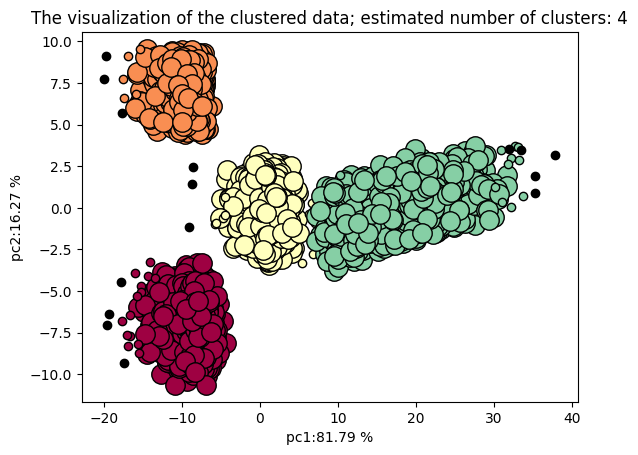

In [25]:
# Plot result

unique_labels = set(labels)
colors = [plt.cm.Spectral(each)
          for each in np.linspace(0, 1, len(unique_labels))]
for k, col in zip(unique_labels, colors):
    if k == -1:
        # Black used for noise.
        col = [0, 0, 0, 1]

    class_member_mask = (labels == k)

    xy = pca_data1[class_member_mask & core_samples_mask]
    plt.plot(xy.iloc[:, 0], xy.iloc[:, 1], 'o', markerfacecolor=tuple(col),
             markeredgecolor='k', markersize=14)

    xy = pca_data1[class_member_mask & ~core_samples_mask]
    plt.plot(xy.iloc[:, 0], xy.iloc[:, 1], 'o', markerfacecolor=tuple(col),
             markeredgecolor='k', markersize=6)

plt.title('The visualization of the clustered data; estimated number of clusters: %d' % n_clusters_)
plt.xlabel("pc1:"+"{:.2f}".format(pca.explained_variance_ratio_[0]*100)+" %")
plt.ylabel("pc2:"+"{:.2f}".format(pca.explained_variance_ratio_[1]*100)+" %")
plt.show()

- 4 clusters are identified by DBSCAN algorithm. The result is plotted in terms of pc1 and pc2. Black points in the graph represent the outliers.

# Comparison of K-Means and DBSCAN
- Both K-means and DBSCAN(with optimal epsilon and min_sample parameter) algorithms give the k = 4 as optimal number of cluster.

- Quality of clustering measured by silhouette score approach which determine how well each object lies within its cluster, high average silhouette width implies good clustering. K-means algorithm has a 0.6718 silhouette score and DBSCAN algorithm has 0.6695 silhouette score.They are nearly same but K-means perform better.

- The cluster which is in the middle of the graph seem more connected than the others. Other cluster has varying density. Since there are local outliers and there is a slight variation in terms of density on the clusters, with epsilon =3.5 and min_samples =20 DBSCAN can identify 4 clusters but K-means outperform.